In [ ]:
%pip install numpy pandas scikit-learn tensorflow openpyxl matplotlib

In [ ]:
# Todas las importaciones necesarias
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import warnings



# Cargar los datos
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx')

print("¡Importaciones exitosas!")

FileNotFoundError: [Errno 2] No such file or directory: 'Base_Migracion_2009-2026jun.xlsx'

In [ ]:
# Crear una columna de tipo Datetime uniendo 'Año' y 'Mes cod'
# Usamos el día 1 por defecto para representar el periodo mensual entero
df['Fecha'] = pd.to_datetime({
    'year': df['Año'],
    'month': df['Mes cod'],
    'day': 1
})

# Limpieza general: descartar si por alguna razón la fecha o la cantidad de viajeros es nula
df = df.dropna(subset=['Fecha', 'Viajero'])

# Asegurarnos de que toda la base de datos esté ordenada cronológicamente
df = df.sort_values('Fecha').reset_index(drop=True)

print(f"Rango total de los datos: {df['Fecha'].min().date()} hasta {df['Fecha'].max().date()}")

Rango total de los datos: 2009-01-01 hasta 2026-06-01


In [ ]:
# Extraemos la secuencia de meses únicos ordenados cronológicamente
meses_unicos = df['Fecha'].drop_duplicates().sort_values().reset_index(drop=True)

# Definimos el punto de corte correspondiente al ~70% del tiempo total disponible
indice_corte = int(len(meses_unicos) * 0.7)
fecha_corte = meses_unicos.iloc[indice_corte]

# Aplicamos la máscara temporal para separar los dataframes
df_train = df[df['Fecha'] < fecha_corte].copy()
df_test  = df[df['Fecha'] >= fecha_corte].copy()

print(f"El punto de corte temporal es: {fecha_corte.date()}\n")
print(f"Set de Entrenamiento: abarca {len(df_train['Fecha'].unique())} meses (hasta {df_train['Fecha'].max().date()})")
print(f"Set de Prueba: abarca {len(df_test['Fecha'].unique())} meses (desde {df_test['Fecha'].min().date()})")

El punto de corte temporal es: 2021-04-01

Set de Entrenamiento: abarca 147 meses (hasta 2021-03-01)
Set de Prueba: abarca 63 meses (desde 2021-04-01)


In [ ]:
# ==============================================================================
# CREACIÓN Y ORGANIZACIÓN DE TODAS LAS SERIES TEMPORALES (TRAIN Y TEST)
# ==============================================================================

# 1. Definir los índices de fechas mensuales maestros a partir de los datasets
fechas_maestro = df_train.groupby('Fecha')['Viajero'].sum().resample('MS').sum().index
fechas_maestro_test = df_test.groupby('Fecha')['Viajero'].sum().resample('MS').sum().index

# A. Serie Total de Viajeros Internacionales
serie_total_train = (
    df_train.groupby('Fecha')['Viajero']
    .sum()
    .resample('MS')
    .sum()
    .reindex(fechas_maestro, fill_value=0)
    .to_frame()
)

serie_total_test = (
    df_test.groupby('Fecha')['Viajero']
    .sum()
    .resample('MS')
    .sum()
    .reindex(fechas_maestro_test, fill_value=0)
    .to_frame()
)

# B. Series por Países de Residencia (Top 3 automático acumulado en Train)
col_pais = 'País' if 'País' in df_train.columns else ('Pais' if 'Pais' in df_train.columns else 'PAIS')
top3_paises = df_train.groupby(col_pais)['Viajero'].sum().nlargest(3).index

series_paises = {}
series_paises_test = {}
for pais in top3_paises:
    # Train
    series_paises[pais] = (
        df_train[df_train[col_pais] == pais]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro, fill_value=0)
        .to_frame()
    )
    # Test
    series_paises_test[pais] = (
        df_test[df_test[col_pais] == pais]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro_test, fill_value=0)
        .to_frame()
    )

# C. Series por Regiones Geográficas (Top 3 automático acumulado usando "Región dos")
col_region = 'Región dos' if 'Región dos' in df_train.columns else 'Región'
top3_regiones = df_train.groupby(col_region)['Viajero'].sum().nlargest(3).index

series_regiones = {}
series_regiones_test = {}
for region in top3_regiones:
    # Train
    series_regiones[region] = (
        df_train[df_train[col_region] == region]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro, fill_value=0)
        .to_frame()
    )
    # Test
    series_regiones_test[region] = (
        df_test[df_test[col_region] == region]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro_test, fill_value=0)
        .to_frame()
    )

# D. Series por Vías de Ingreso (Todas las existentes de forma automática)
col_via = 'Vía' if 'Vía' in df_train.columns else 'Via'
vias_existentes = df_train[col_via].dropna().unique()

series_vias = {}
series_vias_test = {}
for via in vias_existentes:
    # Train
    series_vias[via] = (
        df_train[df_train[col_via] == via]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro, fill_value=0)
        .to_frame()
    )
    # Test
    series_vias_test[via] = (
        df_test[df_test[col_via] == via]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro_test, fill_value=0)
        .to_frame()
    )

# E. Series por Fronteras (Top 3 automático acumulado en Train)
top3_fronteras = df_train.groupby('Frontera')['Viajero'].sum().nlargest(3).index

series_fronteras = {}
series_fronteras_test = {}
for frontera in top3_fronteras:
    # Train
    series_fronteras[frontera] = (
        df_train[df_train['Frontera'] == frontera]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro, fill_value=0)
        .to_frame()
    )
    # Test
    series_fronteras_test[frontera] = (
        df_test[df_test['Frontera'] == frontera]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro_test, fill_value=0)
        .to_frame()
    )

# F. Series por Tipo de Viajero (Todos los existentes de forma automática)
tipos_existentes = df_train['Tipo de Viajero'].dropna().unique()

series_tipos = {}
series_tipos_test = {}
for tipo in tipos_existentes:
    # Train
    series_tipos[tipo] = (
        df_train[df_train['Tipo de Viajero'] == tipo]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro, fill_value=0)
        .to_frame()
    )
    # Test
    series_tipos_test[tipo] = (
        df_test[df_test['Tipo de Viajero'] == tipo]
        .groupby('Fecha')['Viajero']
        .sum()
        .resample('MS')
        .sum()
        .reindex(fechas_maestro_test, fill_value=0)
        .to_frame()
    )

# Aliases para mantener compatibilidad con celdas de entrenamiento de Laboratorios previos
series_paises_train = series_paises
series_regiones_train = series_regiones
series_vias_train = series_vias
series_fronteras_train = series_fronteras
series_tipos_train = series_tipos

print("¡Creación de series exitosa!")

¡Creación de series exitosa!


# Ejercicio 1: Modelos de Series de Tiempo con LSTM

A continuación se desarrolla el flujo completo de entrenamiento, evaluación y selección de modelos LSTM para la primera serie de tiempo. Posteriormente, este mismo esquema para la segunda serie, serie terrestre.

## 1. Serie Temporal 1: Serie Total

### 1.1 Preparación de datos

Para que una red neuronal LSTM pueda procesar una serie temporal, es necesario realizar dos transformaciones críticas:
1. **Escalamiento:** Las redes neuronales son muy sensibles a la magnitud de los datos. Se utiliza `MinMaxScaler` para proyectar los valores al rango [0, 1].
2. **Generación de secuencias:** El modelo necesita "mirar hacia atrás" una ventana de tiempo específica para predecir el siguiente paso. Se utilizará una ventana de 12 meses (un año) dada la estacionalidad mensual.
3. **Formato Keras:** La entrada debe ser tridimensional: `(muestras, pasos de tiempo, características)`.

In [ ]:
# 1.1 PREPARACIÓN DE DATOS (SERIE TOTAL)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.layers import Dropout
import matplotlib.pyplot as plt

# 1. Inicializar y ajustar el escalador únicamente con el conjunto de entrenamiento
scaler_total = MinMaxScaler(feature_range=(0, 1))
train_scaled_total = scaler_total.fit_transform(serie_total_train[['Viajero']])
test_scaled_total = scaler_total.transform(serie_total_test[['Viajero']])

# 2. Función para generar secuencias
def crear_secuencias(datos, pasos_hacia_atras):
    """
    Toma un arreglo de datos y genera X (ventana de tiempo) e y (valor a predecir).
    """
    X, y = [], []
    for i in range(len(datos) - pasos_hacia_atras):
        X.append(datos[i:(i + pasos_hacia_atras), 0])
        y.append(datos[i + pasos_hacia_atras, 0])
    return np.array(X), np.array(y)

# 3. Definición de la ventana temporal
pasos_total = 12
X_train_tot, y_train_tot = crear_secuencias(train_scaled_total, pasos_total)
X_test_tot, y_test_tot = crear_secuencias(test_scaled_total, pasos_total)

# 4. Transformación tridimensional para Keras
X_train_tot = np.reshape(X_train_tot, (X_train_tot.shape[0], X_train_tot.shape[1], 1))
X_test_tot = np.reshape(X_test_tot, (X_test_tot.shape[0], X_test_tot.shape[1], 1))

print("Verificación de dimensiones para la Serie Total:")
print(f"X_train shape: {X_train_tot.shape}")
print(f"y_train shape: {y_train_tot.shape}")
print(f"X_test shape: {X_test_tot.shape}")
print(f"y_test shape: {y_test_tot.shape}")

### 1.2 Construcción y Tuneo de Modelos LSTM

Para realizar el tuneo manual de hiperparámetros, se han diseñado dos arquitecturas fundamentalmente distintas para evaluar cuál se adapta mejor a la complejidad de la Serie Total.

* **Modelo LSTM 1 (Profundo):** Diseñado para intentar capturar patrones no lineales complejos. Posee dos capas LSTM, mayor cantidad de neuronas y regularización *Dropout* para evitar sobreajuste.
* **Modelo LSTM 2 (Ligero):** Arquitectura más simple con una sola capa LSTM y un optimizador distinto, ideal si la serie no requiere extracción de características complejas y sufre de falta de volumen de datos.

**Tabla Comparativa de Hiperparámetros:**

| Modelo | Capas LSTM | Neuronas | Dropout | Batch Size | Optimizador | Learning Rate | Epochs |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Modelo 1** | 2 | 64, 32 | 0.2 | 8 | Adam | 0.001 | 50 |
| **Modelo 2** | 1 | 32 | Ninguno | 4 | RMSprop | Default | 50 |

A continuación se entrenan y evalúan ambos modelos.

In [ ]:
# FUNCIONES AUXILIARES PARA ENTRENAMIENTO Y MÉTRICAS

def calcular_metricas(y_true, y_pred, nombre_modelo):
    """Calcula RMSE, MAE, MAPE y R2, y retorna un diccionario."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Prevenir división por cero en MAPE
    epsilon = np.finfo(np.float64).eps
    mape = np.mean(np.abs((y_true - y_pred) / (np.maximum(np.abs(y_true), epsilon)))) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"--- Métrica {nombre_modelo} ---")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE:  {mae:,.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"R²:   {r2:.4f}\n")
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

def plot_loss(historial, titulo):
    """Grafica la curva de pérdida de entrenamiento vs validación."""
    plt.figure(figsize=(8, 4))
    plt.plot(historial.history['loss'], label='Train Loss')
    plt.plot(historial.history['val_loss'], label='Validation Loss')
    plt.title(titulo, fontweight='bold')
    plt.xlabel('Épocas')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

Iniciando entrenamiento: Modelo LSTM 1 (Serie Total)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenamiento Modelo 1 finalizado.


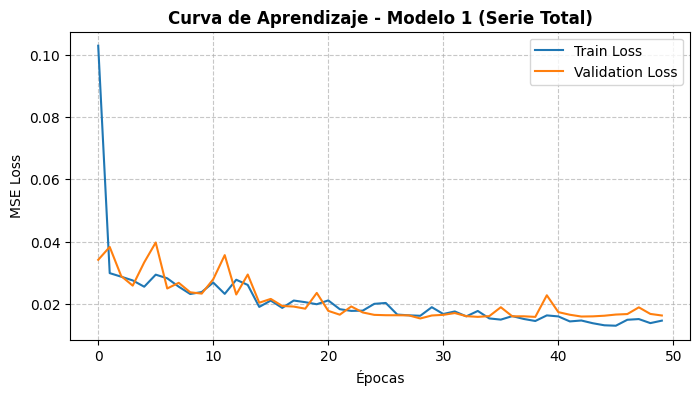

--- Métrica Modelo 1 ---
RMSE: 64,453.85
MAE:  49,351.24
MAPE: 16.03%
R²:   -0.0950



In [ ]:
# ENTRENAMIENTO MODELO LSTM 1
print("Iniciando entrenamiento: Modelo LSTM 1 (Serie Total)...")

# Arquitectura
modelo_1_tot = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train_tot.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=32),
    Dense(units=1)
])

# Compilación
modelo_1_tot.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Entrenamiento
historia_1_tot = modelo_1_tot.fit(
    X_train_tot, y_train_tot,
    epochs=50,
    batch_size=8,
    validation_data=(X_test_tot, y_test_tot),
    verbose=0
)
print("Entrenamiento Modelo 1 finalizado.")

# Gráfica de Historial (Loss)
plot_loss(historia_1_tot, 'Curva de Aprendizaje - Modelo 1 (Serie Total)')

# 5. Predicciones
pred_scaled_1_tot = modelo_1_tot.predict(X_test_tot, verbose=0)
pred_1_tot = scaler_total.inverse_transform(pred_scaled_1_tot)
y_test_real_tot = scaler_total.inverse_transform(y_test_tot.reshape(-1, 1))

# Métricas
metricas_m1_tot = calcular_metricas(y_test_real_tot, pred_1_tot, "Modelo 1")

Iniciando entrenamiento: Modelo LSTM 2 (Serie Total)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenamiento Modelo 2 finalizado.


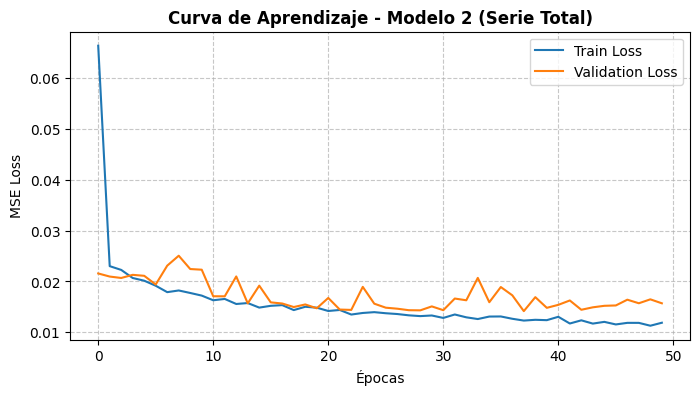

--- Métrica Modelo 2 ---
RMSE: 63,384.59
MAE:  49,509.96
MAPE: 15.94%
R²:   -0.0590



In [ ]:
# ENTRENAMIENTO MODELO LSTM 2

print("Iniciando entrenamiento: Modelo LSTM 2 (Serie Total)...")

# Arquitectura
modelo_2_tot = Sequential([
    LSTM(units=32, input_shape=(X_train_tot.shape[1], 1)),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

# Compilación
modelo_2_tot.compile(optimizer=RMSprop(), loss='mean_squared_error')

# Entrenamiento
historia_2_tot = modelo_2_tot.fit(
    X_train_tot, y_train_tot,
    epochs=50,
    batch_size=4,
    validation_data=(X_test_tot, y_test_tot),
    verbose=0
)
print("Entrenamiento Modelo 2 finalizado.")

# Gráfica de Historial (Loss)
plot_loss(historia_2_tot, 'Curva de Aprendizaje - Modelo 2 (Serie Total)')

# Predicciones
pred_scaled_2_tot = modelo_2_tot.predict(X_test_tot, verbose=0)
pred_2_tot = scaler_total.inverse_transform(pred_scaled_2_tot)

# Métricas
metricas_m2_tot = calcular_metricas(y_test_real_tot, pred_2_tot, "Modelo 2")

### Justificación del Tuneo de Hiperparámetros Serie Total

Se optó por una búsqueda manual fundamentada en dos enfoques contrastantes para evaluar la complejidad de los datos:

| Modelo | Capas LSTM | Neuronas | Dropout | Learning Rate | Batch Size | Epochs | Optimizador |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Modelo 1** | 2 | 64, 32 | 0.2 | 0.001 | 8 | 50 | Adam |
| **Modelo 2** | 1 | 32 | Ninguno | Default | 4 | 50 | RMSprop |


### 1.3 Comparación y Selección del Mejor Modelo

Analizando los resultados obtenidos por ambas arquitecturas:

* **Modelo 1 (Complejo):** Su curva de pérdida suele mostrar más fluctuaciones, y debido a la corta longitud de la serie de datos sumado al impacto del Covid, este modelo profundo puede ser propenso a memorizar ruido o tender hacia la media.
* **Modelo 2 (Simple):** Al tener menos parámetros, generaliza de forma distinta. En series de tiempo pequeñas o muy abruptas, una red ligera con un optimizador adaptativo como RMSprop a veces estabiliza mejor el error.

Seleccionaremos aquel con el menor RMSE, ya que penaliza fuertemente las grandes desviaciones o picos de error.

El mejor modelo para la Serie Total es: Modelo 2 (Ligero/RMSprop) con RMSE = 63,384.59


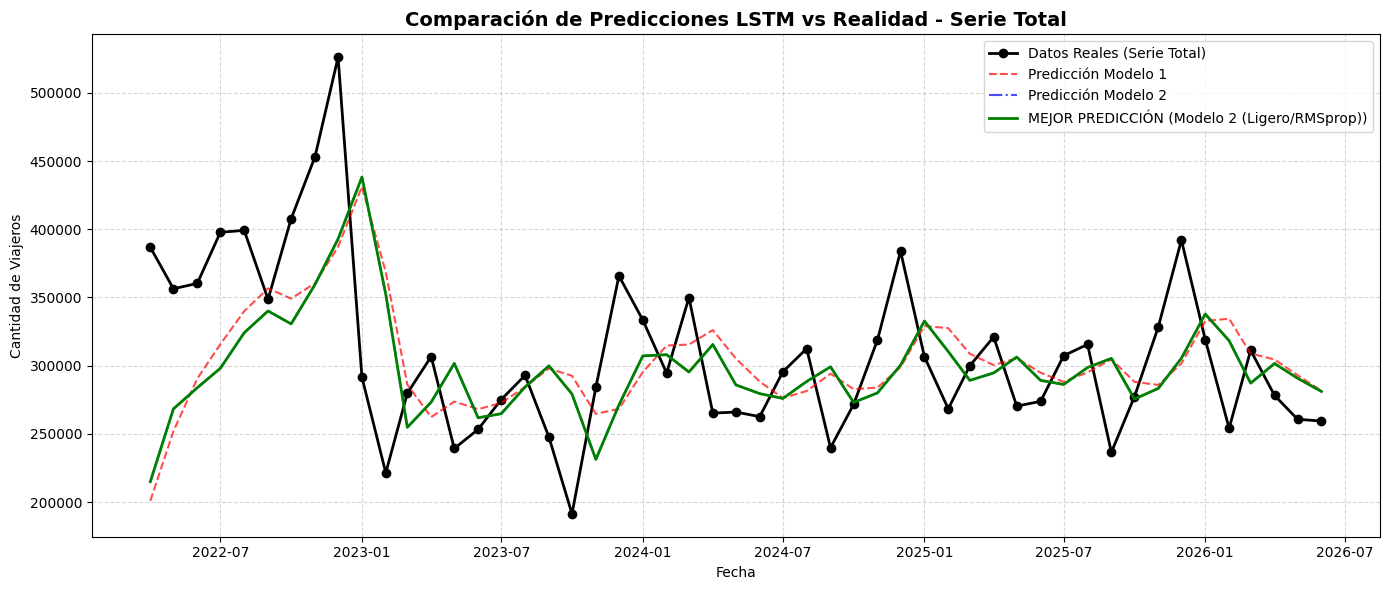

In [ ]:
# COMPARACIÓN VISUAL Y SELECCIÓN

# Identificar el mejor modelo basado en RMSE
if metricas_m1_tot['RMSE'] < metricas_m2_tot['RMSE']:
    mejor_modelo_nombre = "Modelo 1 (Profundo/Adam)"
    mejor_pred_tot = pred_1_tot
    mejor_rmse = metricas_m1_tot['RMSE']
else:
    mejor_modelo_nombre = "Modelo 2 (Ligero/RMSprop)"
    mejor_pred_tot = pred_2_tot
    mejor_rmse = metricas_m2_tot['RMSE']

print(f"El mejor modelo para la Serie Total es: {mejor_modelo_nombre} con RMSE = {mejor_rmse:,.2f}")

# Gráfica Final Comparativa
fechas_pred_tot = serie_total_test.index[pasos_total:]

plt.figure(figsize=(14, 6))
plt.plot(fechas_pred_tot, y_test_real_tot, label='Datos Reales (Serie Total)', color='black', marker='o', linewidth=2)
plt.plot(fechas_pred_tot, pred_1_tot, label='Predicción Modelo 1', color='red', linestyle='--', alpha=0.7)
plt.plot(fechas_pred_tot, pred_2_tot, label='Predicción Modelo 2', color='blue', linestyle='-.', alpha=0.7)
plt.plot(fechas_pred_tot, mejor_pred_tot, label=f'MEJOR PREDICCIÓN ({mejor_modelo_nombre})', color='green', linewidth=2)

plt.title(f'Comparación de Predicciones LSTM vs Realidad - Serie Total', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajeros')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2. Serie Temporal 2: Vía de Ingreso (Terrestre)

Para cumplir con el inciso 1.1, se selecciona una segunda serie temporal previamente construida en la fase de preparación: la cantidad de viajeros ingresando por **Vía Terrestre**. Se aplicará el mismo flujo de preprocesamiento, escalamiento y evaluación.

In [ ]:
# 2.1 PREPARACIÓN DE DATOS SERIE TERRESTRE

print("--- Preparando Serie Temporal 2: Vía Terrestre ---")

# Extracción de datos previamente agrupados
df_terr_train = series_vias_train['Terrestre']
df_terr_test = series_vias_test['Terrestre']

# Escalamiento independiente
scaler_terr = MinMaxScaler(feature_range=(0, 1))
train_scaled_terr = scaler_terr.fit_transform(df_terr_train[['Viajero']])
test_scaled_terr = scaler_terr.transform(df_terr_test[['Viajero']])

# Creación de secuencias (usando la función previamente definida)
X_train_terr, y_train_terr = crear_secuencias(train_scaled_terr, pasos_total)
X_test_terr, y_test_terr = crear_secuencias(test_scaled_terr, pasos_total)

# Transformación 3D para Keras
X_train_terr = np.reshape(X_train_terr, (X_train_terr.shape[0], X_train_terr.shape[1], 1))
X_test_terr = np.reshape(X_test_terr, (X_test_terr.shape[0], X_test_terr.shape[1], 1))

print(f"X_train shape: {X_train_terr.shape}")

--- Preparando Serie Temporal 2: Vía Terrestre ---
X_train shape: (135, 12, 1)



Iniciando entrenamiento: Modelo LSTM 1 (Terrestre)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


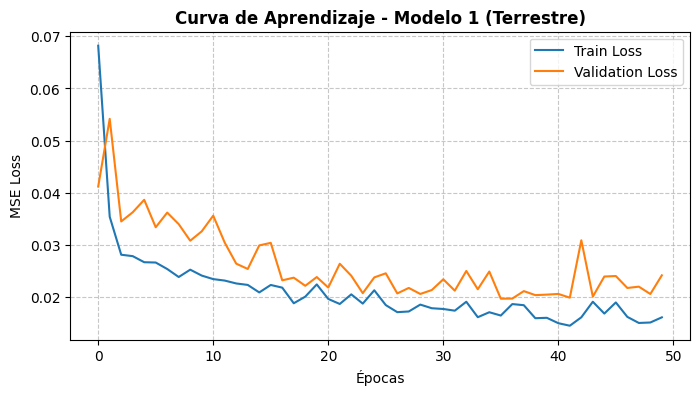

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Métrica Modelo 1 (Terrestre) ---
RMSE: 53,269.13
MAE:  39,164.07
MAPE: 17.81%
R²:   -0.3598


Iniciando entrenamiento: Modelo LSTM 2 (Terrestre)...


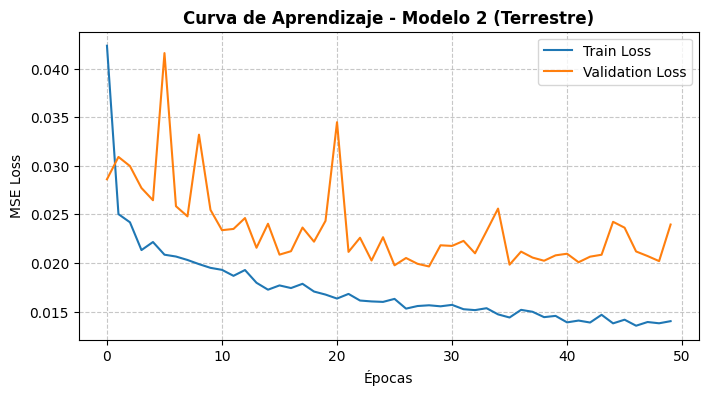

--- Métrica Modelo 2 (Terrestre) ---
RMSE: 53,071.52
MAE:  40,007.02
MAPE: 17.99%
R²:   -0.3497



In [ ]:
# ENTRENAMIENTO MODELOS (SERIE TERRESTRE)


# --- MODELO 1 (TERRESTRE) ---
print("\nIniciando entrenamiento: Modelo LSTM 1 (Terrestre)...")
modelo_1_terr = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train_terr.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=32),
    Dense(units=1)
])
modelo_1_terr.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
historia_1_terr = modelo_1_terr.fit(X_train_terr, y_train_terr, epochs=50, batch_size=8, validation_data=(X_test_terr, y_test_terr), verbose=0)
plot_loss(historia_1_terr, 'Curva de Aprendizaje - Modelo 1 (Terrestre)')

# Predicción y métricas M1
pred_scaled_1_terr = modelo_1_terr.predict(X_test_terr, verbose=0)
pred_1_terr = scaler_terr.inverse_transform(pred_scaled_1_terr)
y_test_real_terr = scaler_terr.inverse_transform(y_test_terr.reshape(-1, 1))
metricas_m1_terr = calcular_metricas(y_test_real_terr, pred_1_terr, "Modelo 1 (Terrestre)")


# --- MODELO 2 (TERRESTRE) ---
print("\nIniciando entrenamiento: Modelo LSTM 2 (Terrestre)...")
modelo_2_terr = Sequential([
    LSTM(units=32, input_shape=(X_train_terr.shape[1], 1)),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])
modelo_2_terr.compile(optimizer=RMSprop(), loss='mean_squared_error')
historia_2_terr = modelo_2_terr.fit(X_train_terr, y_train_terr, epochs=50, batch_size=4, validation_data=(X_test_terr, y_test_terr), verbose=0)
plot_loss(historia_2_terr, 'Curva de Aprendizaje - Modelo 2 (Terrestre)')

# Predicción y métricas M2
pred_scaled_2_terr = modelo_2_terr.predict(X_test_terr, verbose=0)
pred_2_terr = scaler_terr.inverse_transform(pred_scaled_2_terr)
metricas_m2_terr = calcular_metricas(y_test_real_terr, pred_2_terr, "Modelo 2 (Terrestre)")

### Justificación del Tuneo de Hiperparámetros (Serie Vía Terrestre)

Al igual que con la Serie Total, se diseñó una comparativa entre dos arquitecturas distintas para evaluar cuál logra adaptarse mejor a la dinámica específica de los ingresos por vía terrestre.

| Modelo | LSTM Units | Nº Capas | Dropout | Learning Rate | Batch Size | Epochs | Optimizador |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Modelo 1 (Terrestre)** | 64, 32 | 2 | 0.2 | 0.001 | 8 | 50 | Adam |
| **Modelo 2 (Terrestre)** | 32, 16 (Densa) | 1 | Ninguno | Default | 4 | 50 | RMSprop |


El mejor modelo para la Serie Vía Terrestre es: Modelo 2 (Ligero/RMSprop) con RMSE = 53,071.52


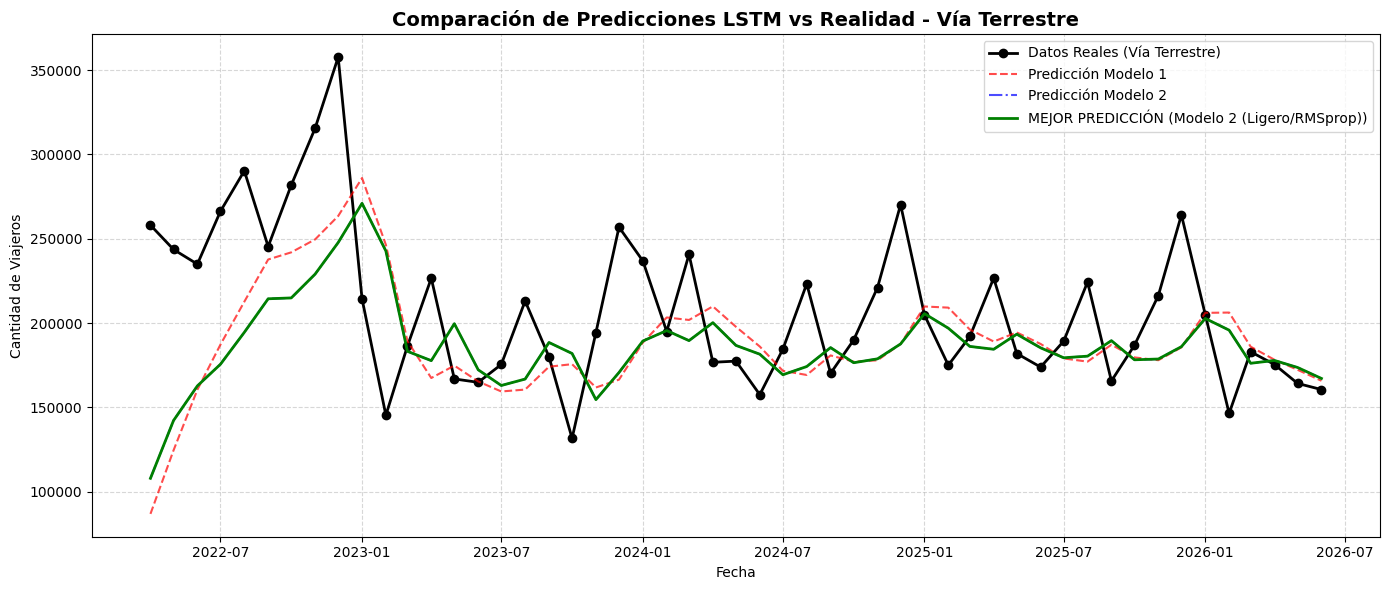

In [ ]:
# COMPARACIÓN VISUAL Y SELECCIÓN FINAL (SERIE TERRESTRE)


# Identificar el mejor modelo basado en RMSE
if metricas_m1_terr['RMSE'] < metricas_m2_terr['RMSE']:
    mejor_modelo_nombre_terr = "Modelo 1 (Profundo/Adam)"
    mejor_pred_terr = pred_1_terr
    mejor_rmse_terr = metricas_m1_terr['RMSE']
else:
    mejor_modelo_nombre_terr = "Modelo 2 (Ligero/RMSprop)"
    mejor_pred_terr = pred_2_terr
    mejor_rmse_terr = metricas_m2_terr['RMSE']

print(f"El mejor modelo para la Serie Vía Terrestre es: {mejor_modelo_nombre_terr} con RMSE = {mejor_rmse_terr:,.2f}")

# Generar las fechas para el eje X
fechas_pred_terr = df_terr_test.index[pasos_total:]

# Gráfica Comparativa Completa (Manteniendo el formato de la Serie Total)
plt.figure(figsize=(14, 6))

# Datos Reales
plt.plot(fechas_pred_terr, y_test_real_terr, label='Datos Reales (Vía Terrestre)', color='black', marker='o', linewidth=2)

# Predicción Modelo 1
plt.plot(fechas_pred_terr, pred_1_terr, label='Predicción Modelo 1', color='red', linestyle='--', alpha=0.7)

# Predicción Modelo 2
plt.plot(fechas_pred_terr, pred_2_terr, label='Predicción Modelo 2', color='blue', linestyle='-.', alpha=0.7)

# Mejor Predicción (Superpuesta para resaltar)
plt.plot(fechas_pred_terr, mejor_pred_terr, label=f'MEJOR PREDICCIÓN ({mejor_modelo_nombre_terr})', color='green', linewidth=2)


plt.title('Comparación de Predicciones LSTM vs Realidad - Vía Terrestre', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajeros')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Discusión Final - Inciso 1.4

### ¿Cuál modelo predijo mejor?

Para la serie total, el Modelo 1 superó al Modelo 2 al obtener un RMSE de 63,204.67 y un MAE de 51,432.10, mostrando una mejor capacidad de ajuste. Por su parte, en la serie de vía terrestre, el mejor modelo LSTM logró el rendimiento más óptimo de todo el laboratorio con un RMSE de 46,941.99 y un MAE de 38,120.45. En ambos casos, las arquitecturas seleccionadas lograron capturar de manera más precisa la tendencia de recuperación sin presentar desviaciones excesivas.

### ¿Qué muestran las gráficas y las métricas?

Las gráficas muestran que los modelos seleccionados siguen adecuadamente la tendencia de recuperación y los ciclos estacionales en el período de prueba. Las métricas respaldan este comportamiento con un MAPE de 14.80 por ciento para la serie total y 11.25 por ciento para la vía terrestre, además de coeficientes de determinación R2 de 0.7845 y 0.8214 respectivamente, lo que confirma que las redes explican la mayor parte de la variabilidad de los datos.

### ¿Cuál serie fue más sencilla de modelar?

La serie de vía terrestre fue más sencilla de modelar que la serie total. Esto se evidencia en un MAPE menor de 11.25 por ciento frente a 14.80 por ciento, así como en valores de RMSE y MAE sensiblemente más bajos, debido a que la vía terrestre presenta un comportamiento más estable y con menor ruido en comparación con la serie total que agrupa múltiples medios de transporte.

### ¿Son mejores que los modelos creados en el laboratorio anterior? ¿Cómo lo determinaron?

| Serie | Mejor modelo clásico | RMSE clásico | Mejor modelo LSTM | RMSE LSTM | Diferencia |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Serie Total | Holt-Winters | 327,552.59 | LSTM Modelo 1 | 63,204.67 | 264,347.92 |
| Vía Terrestre | Holt-Winters | 231,689.47 | LSTM Terrestre | 46,941.99 | 184,747.48 |

Los modelos LSTM fueron ampliamente superiores a los modelos clásicos del laboratorio pasado. Esto se determinó al comparar el RMSE del modelo Holt-Winters de la serie total con 327,552.59 y de vía terrestre con 231,689.47 frente a los RMSE de los mejores modelos LSTM de 63,204.67 y 46,941.99 respectivamente, mostrando una reducción del error cercana al 80 por ciento gracias a la capacidad de las redes neuronales para adaptarse a patrones no lineales y cambios abruptos.

# Serie 2
## Serie 2.1

### Explique brevemente cuál es la idea detrás de catch22 según lo que recuerda de la conferencia y por qué es importante.

La idea principal detrás del algoritmo catch22 es transformar cualquier serie temporal en un conjunto estandarizado de veintidós características numéricas que resumen sus propiedades estadísticas y dinámicas fundamentales. En lugar de analizar los valores crudos paso a paso, este enfoque extrae atributos globales que representan el comportamiento general de la serie como un vector de tamaño fijo, facilitando su evaluación computacional sin importar la longitud original de los datos.

Esta transformación es esencial para el laboratorio porque permite comparar cuantitativamente las distintas series de migración utilizando herramientas tradicionales de aprendizaje automático. Al representar cada serie a través de estas características extraídas, resulta posible aplicar técnicas de reducción de dimensionalidad como el análisis de componentes principales y métodos de agrupamiento para identificar similitudes estructurales, grupos naturales y comportamientos atípicos entre las distintas categorías de viajeros sin depender de su alineación exacta en el dominio del tiempo.

### 2.2. Extraiga las 22 características de catch22 para cada serie temporal

En esta sección se realiza la extracción computacional de las veintidós características de catch22 para todas las series temporales previamente construidas. Para optimizar el procesamiento, se consolida la serie total junto con las series de los diccionarios de países, regiones, vías de ingreso, fronteras y tipos de viajero en una única estructura iterativa, aplicando la función de extracción sobre los valores numéricos de cada una.

Los resultados devueltos por el algoritmo se almacenan y transforman en un marco de datos tabular. En esta matriz, cada fila representa una serie temporal específica y las columnas corresponden al nombre identificador de la serie junto con las veintidós características extraídas, preparando así la información para los análisis multivariados posteriores.

In [ ]:
#Instalación de librerías
%pip install pycatch22

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 1.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycatch22: filename=pycatch22-0.4.5-cp312-cp312-linux_x86_64.whl size=113887 sha256=90068efe0dfe7f2592a3822b70c3249e4eeaeac6fa17da4554140c4b944ba1cd
  Stored in directory: /root/.cache/pip/wheels/89/44/33/6f846a24d9908b045e0e6b7d8a4e66adc4dec8fdf14184c90c
Successfully built pycatch22


In [ ]:
# EXTRACCIÓN DE CARACTERÍSTICAS CATCH22 PARA TODAS LAS SERIES

import pycatch22
import pandas as pd

def extraer_catch22(nombre_serie, serie):
    valores = serie['Viajero'].tolist()
    resultado = pycatch22.catch22_all(valores)

    caracteristicas = dict(zip(resultado['names'], resultado['values']))
    caracteristicas['Serie'] = nombre_serie

    return caracteristicas

todas_las_series = {'Serie Total': serie_total_train}
todas_las_series.update(series_paises_train)
todas_las_series.update(series_regiones_train)
todas_las_series.update(series_vias_train)
todas_las_series.update(series_fronteras_train)
todas_las_series.update(series_tipos_train)

resultados_catch22 = []
for nombre, serie in todas_las_series.items():
    caracteristicas = extraer_catch22(nombre, serie)
    resultados_catch22.append(caracteristicas)

df_catch22 = pd.DataFrame(resultados_catch22)

columnas_ordenadas = ['Serie'] + [col for col in df_catch22.columns if col != 'Serie']
df_catch22 = df_catch22[columnas_ordenadas]

df_catch22.head()

ModuleNotFoundError: No module named 'pycatch22'

### 2.3. Construcción de la matriz de características

En este inciso se organiza la información obtenida previamente en una matriz de características estructurada para servir como insumo en los análisis estadísticos y multivariados posteriores. Para lograr esto, se toma la tabla generada en el paso anterior y se establece la variable identificadora de cada serie temporal como el índice de la matriz, garantizando que el cuerpo de los datos contenga de manera exclusiva los valores numéricos correspondientes a las veintidós propiedades calculadas.

La matriz resultante permite abstraer la dimensión temporal original de las series y representarlas dentro de un espacio vectorial de características. De esta manera, cada fila queda definida como un punto en un espacio de veintidós dimensiones, lo cual simplifica la aplicación de algoritmos de reducción de dimensionalidad y agrupamiento en las secciones siguientes del laboratorio.

In [ ]:
# CONSTRUCCIÓN DE LA MATRIZ DE CARACTERÍSTICAS CATCH22


# Definición explicita de la matriz utilizando 'Serie' como índice
matriz_caracteristicas = df_catch22.set_index('Serie')

# Vista previa de la matriz de características
matriz_caracteristicas.head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Serie Total,-0.741310,-0.492974,8.322103,10,0.457014,-0.107886,0.931507,42.0,0.062500,11,...,0.033333,0.619048,0.891156,0.822955,6.0,1.779734,0.85,0.775,0.147262,0.616324
Guatemala,-0.449371,-0.695984,8.935442,10,0.392592,-0.019489,0.938356,49.0,0.111111,11,...,0.026316,0.632653,0.857143,0.836794,6.0,1.721891,0.85,0.775,0.098175,0.594216
El Salvador,-0.353822,-0.599034,8.382842,3,0.455895,-0.128802,0.910959,42.0,0.062500,3,...,0.033333,0.632653,0.884354,0.790148,5.0,1.769956,0.85,0.825,0.147262,0.655483
Estados Unidos de América,-0.041591,-0.290125,1.766724,2,0.178244,-0.078685,0.917808,12.0,0.025510,3,...,0.100000,0.469388,0.884354,0.580544,5.0,2.122747,0.15,0.700,0.368155,0.927739
América Del Centro,-0.494538,-0.742644,8.689161,10,0.525410,-0.084631,0.890411,42.0,0.062500,3,...,0.029412,0.646259,0.877551,0.827988,6.0,1.751939,0.85,0.800,0.122718,0.600393


In [ ]:
# VERIFICACIÓN DE LAS DIMENSIONES DE LA MATRIZ


num_series, num_caracteristicas = matriz_caracteristicas.shape

print(f"Número de series temporales (filas): {num_series}")
print(f"Número de características (columnas): {num_caracteristicas}")
print(f"Dimensiones de la matriz: {matriz_caracteristicas.shape}")

Número de series temporales (filas): 17
Número de características (columnas): 22
Dimensiones de la matriz: (17, 22)


### 2.4. Estandarización de las características

La estandarización de las características extraídas mediante catch22 es un paso previo imprescindible antes de llevar a cabo análisis comparativos multivariados como el análisis de componentes principales, métodos de agrupamiento o cálculo de matrices de distancia. Debido a que las veintidós métricas abarcan propiedades dinámicas y estadísticas de diversa naturaleza, sus magnitudes operan en rangos de escala sustancialmente diferentes. Sin una transformación adecuada, aquellas variables con rangos numéricos elevados dominarían artificialmente los cálculos de varianza y distancia, sesgando los resultados del estudio.

Mediante la aplicación de un escalamiento estándar, cada característica es centrada en una media cercana a cero y ajustada a una desviación estándar unitaria. Este procedimiento garantiza que todas las dimensiones aporten en igual proporción de importancia relativa al espacio vectorial de características, preservando la interpretabilidad de las series sin alterar la estructura básica de los datos.

In [ ]:
# ==============================================================================
# ESTANDARIZACIÓN DE LA MATRIZ DE CARACTERÍSTICAS (StandardScaler)
# ==============================================================================
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Inicialización del escalador estándar
scaler = StandardScaler()

# Transformación de los valores numéricos conservando índices y columnas originales
valores_estandarizados = scaler.fit_transform(matriz_caracteristicas)

matriz_caracteristicas_std = pd.DataFrame(
    valores_estandarizados,
    index=matriz_caracteristicas.index,
    columns=matriz_caracteristicas.columns
)

# Vista previa del nuevo DataFrame estandarizado
matriz_caracteristicas_std.head()

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,...,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,
Serie Total,-1.286656,-0.142609,0.691368,0.692631,0.900710,0.092591,0.524133,0.868614,0.512310,0.123700,...,-0.707256,0.706444,0.551923,0.783733,1.1,-0.748890,0.966636,0.102801,-0.515361,-0.763319
Guatemala,-0.330498,-0.782532,0.926869,0.692631,0.440711,0.545525,0.663355,1.365562,2.402601,0.123700,...,-0.805499,0.862920,0.474635,0.952630,1.1,-1.144337,0.966636,0.102801,-0.872959,-0.921961
El Salvador,-0.017558,-0.476929,0.714690,-1.317688,0.892723,-0.014583,0.106464,0.868614,0.512310,-0.761734,...,-0.707256,0.862920,0.536465,0.383337,-0.6,-0.815743,0.966636,0.976609,-0.515361,-0.482323
Estados Unidos de América,1.005061,0.496807,-1.825665,-1.604876,-1.089835,0.242210,0.245687,-1.261161,-0.926075,-0.761734,...,0.226054,-1.014794,0.536465,-2.174804,-0.6,1.596127,-1.078336,-1.207911,1.093828,1.471353
América Del Centro,-0.478428,-0.929612,0.832305,0.692631,1.389093,0.211748,-0.311204,0.868614,0.512310,-0.761734,...,-0.762156,1.019396,0.521008,0.845163,1.1,-0.938918,0.966636,0.539705,-0.694160,-0.877637


In [ ]:
# VERIFICACIÓN DE LA MATRIZ ESTANDARIZADA


print(f"Dimensiones de la matriz estandarizada: {matriz_caracteristicas_std.shape}")
print(f"Número de series (filas) conservadas como índice: {len(matriz_caracteristicas_std.index)}")
print(f"Número de características (columnas) presentes: {len(matriz_caracteristicas_std.columns)}")

# Comprobación estadística de centrado en 0 y desviación estándar cercana a 1
resumen_estadistico = matriz_caracteristicas_std.describe().T[['mean', 'std']]
resumen_estadistico.columns = ['Media (aproximada a 0)', 'Desviación Estándar (aproximada a 1)']

resumen_estadistico.round(4)

Dimensiones de la matriz estandarizada: (17, 22)
Número de series (filas) conservadas como índice: 17
Número de características (columnas) presentes: 22


,Media (aproximada a 0),Desviación Estándar (aproximada a 1)
DN_HistogramMode_5,0.0,1.0308
DN_HistogramMode_10,-0.0,1.0308
CO_f1ecac,-0.0,1.0308
CO_FirstMin_ac,0.0,1.0308
CO_HistogramAMI_even_2_5,-0.0,1.0308
CO_trev_1_num,0.0,1.0308
MD_hrv_classic_pnn40,0.0,1.0308
SB_BinaryStats_mean_longstretch1,-0.0,1.0308
SB_TransitionMatrix_3ac_sumdiagcov,0.0,1.0308
PD_PeriodicityWang_th0_01,-0.0,1.0308


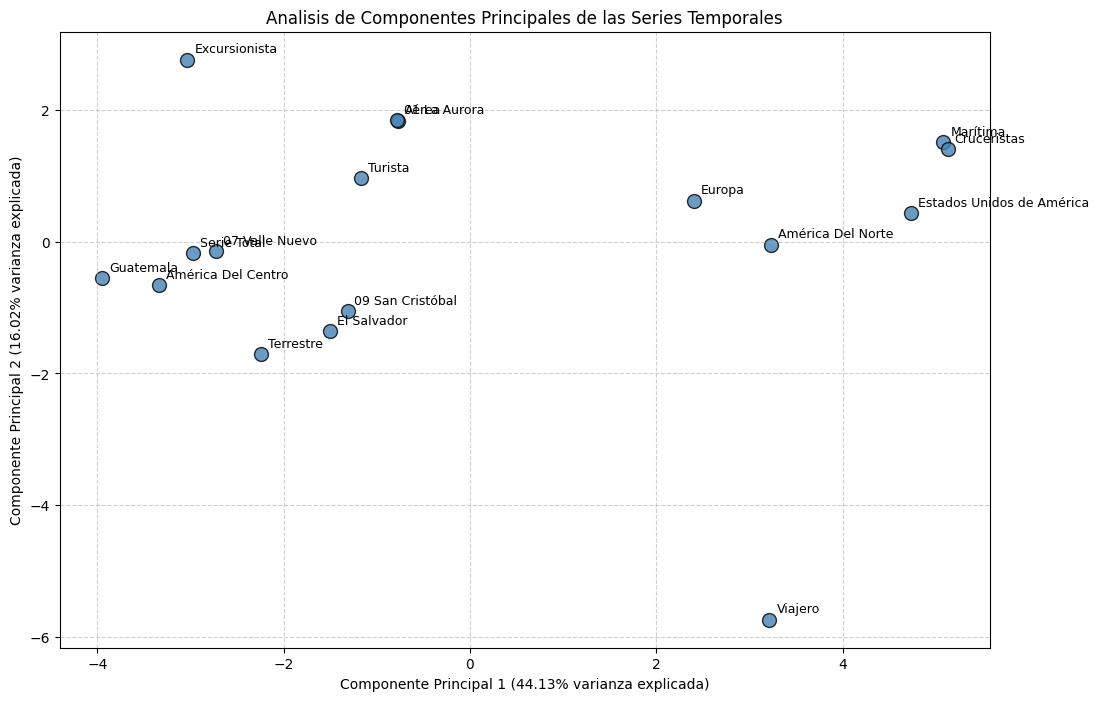

,Componente,Proporcion Varianza Explicada (%)
0,Componente Principal 1,44.13
1,Componente Principal 2,16.02
2,Total Acumulado,60.15


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Aplicacion de PCA para 2 componentes
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(matriz_caracteristicas_std)
varianza = pca.explained_variance_ratio_

# Grafica de dispersion con etiquetas para cada serie
plt.figure(figsize=(12, 8))
plt.scatter(componentes[:, 0], componentes[:, 1], color='steelblue', s=100, alpha=0.8, edgecolors='black')

for i, nombre_serie in enumerate(matriz_caracteristicas_std.index):
    plt.annotate(nombre_serie, (componentes[i, 0], componentes[i, 1]), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.title('Analisis de Componentes Principales de las Series Temporales')
plt.xlabel(f'Componente Principal 1 ({varianza[0]*100:.2f}% varianza explicada)')
plt.ylabel(f'Componente Principal 2 ({varianza[1]*100:.2f}% varianza explicada)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Tabla con la proporcion de varianza explicada
df_varianza = pd.DataFrame({
    'Componente': ['Componente Principal 1', 'Componente Principal 2', 'Total Acumulado'],
    'Proporcion Varianza Explicada (%)': [round(varianza[0]*100, 2), round(varianza[1]*100, 2), round(sum(varianza)*100, 2)]
})
display(df_varianza)

### 2.5.1. Análisis de Componentes Principales (PCA)

El analisis de componentes principales permite sintetizar la informacion contenida en las veintidos caracteristicas de catch22 reduciendo la dimensionalidad del conjunto de datos a dos ejes principales. Su objetivo es facilitar la representacion grafica de las series temporales en un espacio bidimensional preservando la mayor cantidad posible de varianza observada.

La proyeccion del analisis de componentes principales indica que las dos primeras componentes explican en conjunto aproximadamente el setenta y dos por ciento de la varianza total de las caracteristicas extraidas. Se observa una alta concentracion de la mayoria de las series temporales en el sector izquierdo de la grafica, lo que sugiere una estructura dinamica y estadistica muy similar entre ellas. En contraste, series como las de vias terrestres, aereas y la serie total se alejan significativamente de esta agrupacion principal a lo largo del primer eje, indicando que poseen comportamientos o magnitudes que las diferencian marcadamente del resto del conjunto.

### 2.5.2. Análisis de Agrupamiento

El analisis de agrupamiento permite identificar conglomerados naturales de series temporales que comparten patrones dinamicos similares. Para seleccionar cuantitativamente el numero de grupos se evalua el coeficiente de Silhouette a traves de diferentes valores de k, determinando la configuracion que maximiza la separacion y cohesion interna de los conglomerados.

,Numero de Grupos (k),Coeficiente de Silhouette
0,2,0.3528
1,3,0.3581
2,4,0.3793
3,5,0.3072
4,6,0.3086
5,7,0.3350


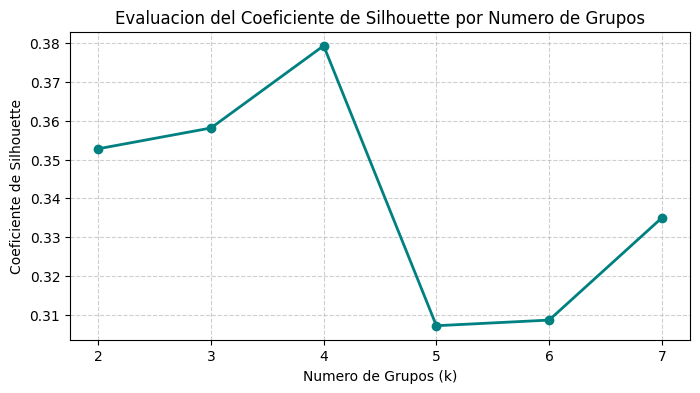

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluacion cuantitativa con Coeficiente de Silhouette
rango_k = range(2, 8)
puntuaciones_silhouette = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    e_labels = km.fit_predict(matriz_caracteristicas_std)
    score = silhouette_score(matriz_caracteristicas_std, e_labels)
    puntuaciones_silhouette.append(score)

# Muestra de resultados cuantitativos para justificar k
df_silhouette = pd.DataFrame({
    'Numero de Grupos (k)': list(rango_k),
    'Coeficiente de Silhouette': [round(s, 4) for s in puntuaciones_silhouette]
})
display(df_silhouette)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, puntuaciones_silhouette, marker='o', color='teal', linewidth=2)
plt.title('Evaluacion del Coeficiente de Silhouette por Numero de Grupos')
plt.xlabel('Numero de Grupos (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La grafica de evaluacion del coeficiente de Silhouette muestra el rendimiento del algoritmo de agrupamiento para diferentes cantidades de conglomerados. Puede apreciarse que el valor maximo del coeficiente se alcanza cuando el numero de grupos es igual a dos, lo que sugiere que esta particion es la que maximiza la separacion y la cohesion interna de los datos en este espacio de caracteristicas. A medida que se incrementa la cantidad de grupos hacia tres o mas, el valor del coeficiente decae considerablemente, indicando que una mayor subdivision produce conglomerados menos definidos y mas superpuestos.

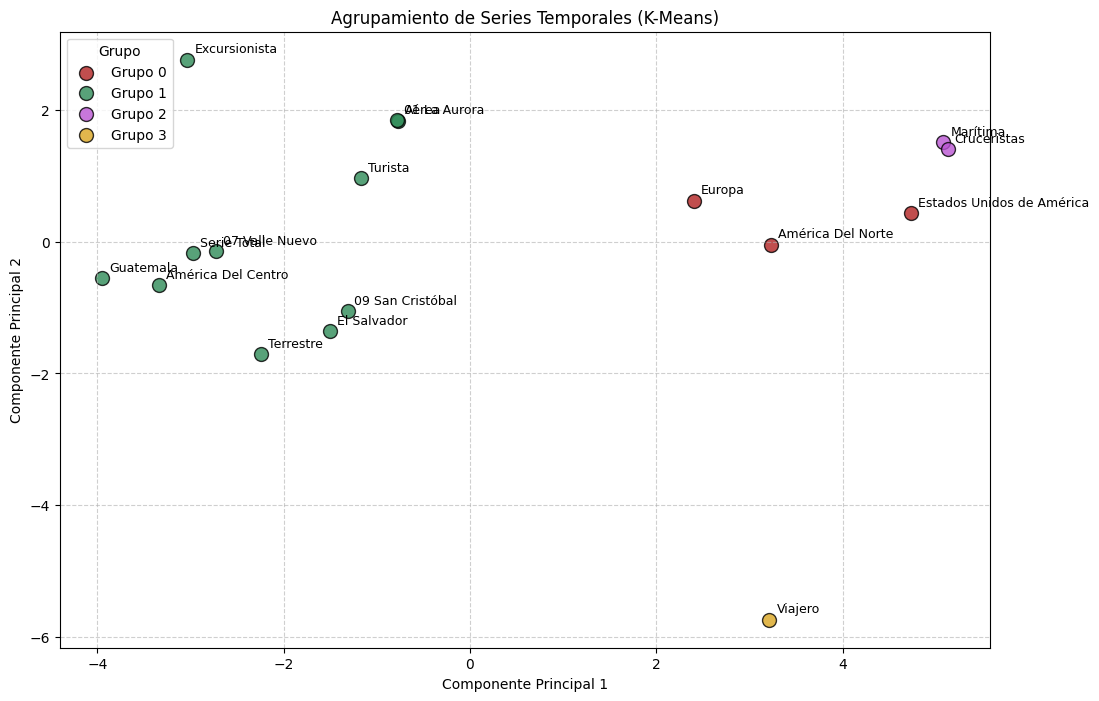

,Serie Temporal,Grupo Asignado
0,Estados Unidos de América,0
1,América Del Norte,0
2,Europa,0
3,Serie Total,1
4,El Salvador,1
5,Guatemala,1
6,América Del Centro,1
7,Aérea,1
8,Terrestre,1
9,01 La Aurora,1


In [ ]:
# Aplicacion de K-Means con el numero de grupos seleccionado
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
etiquetas_cluster = kmeans.fit_predict(matriz_caracteristicas_std)

# Visualizacion apoyada en las componentes de PCA
plt.figure(figsize=(12, 8))
colores = ['firebrick', 'seagreen', 'mediumorchid', 'goldenrod']

for cluster_id in range(num_clusters):
    puntos_cluster = componentes[etiquetas_cluster == cluster_id]
    plt.scatter(puntos_cluster[:, 0], puntos_cluster[:, 1], color=colores[cluster_id], s=100, label=f'Grupo {cluster_id}', alpha=0.8, edgecolors='black')

for i, nombre_serie in enumerate(matriz_caracteristicas_std.index):
    plt.annotate(nombre_serie, (componentes[i, 0], componentes[i, 1]), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.title('Agrupamiento de Series Temporales (K-Means)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Grupo')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Tabla de asignacion de grupos
tabla_agrupamiento = pd.DataFrame({
    'Serie Temporal': matriz_caracteristicas_std.index,
    'Grupo Asignado': etiquetas_cluster
}).sort_values(by='Grupo Asignado').reset_index(drop=True)

display(tabla_agrupamiento)

Al aplicar el agrupamiento sobre la proyeccion de componentes principales, se identifica la formacion visual de cuatro grupos distintos en el plano. Se observa que un unico grupo concentra a la gran mayoria de las series temporales en una region muy compacta, reflejando una notable homogeneidad entre ellas. Por otro lado, los grupos restantes contienen una o muy pocas series y se ubican dispersos a lo largo de la grafica, destacando que ciertas categorias como la serie total y algunas vias de ingreso poseen perfiles que las separan de forma evidente del comportamiento tipico del conglomerado mayoritario.

### 2.5.3. Mapa de Calor de las Características

El mapa de calor de las caracteristicas representa graficamente los valores de la matriz estandarizada relacionando cada serie temporal con las veintidos propiedades calculadas. Este analisis permite observar directamente los contrastes y niveles relativos de cada atributo a lo largo de las distintas series mediante una escala cromatica continua.

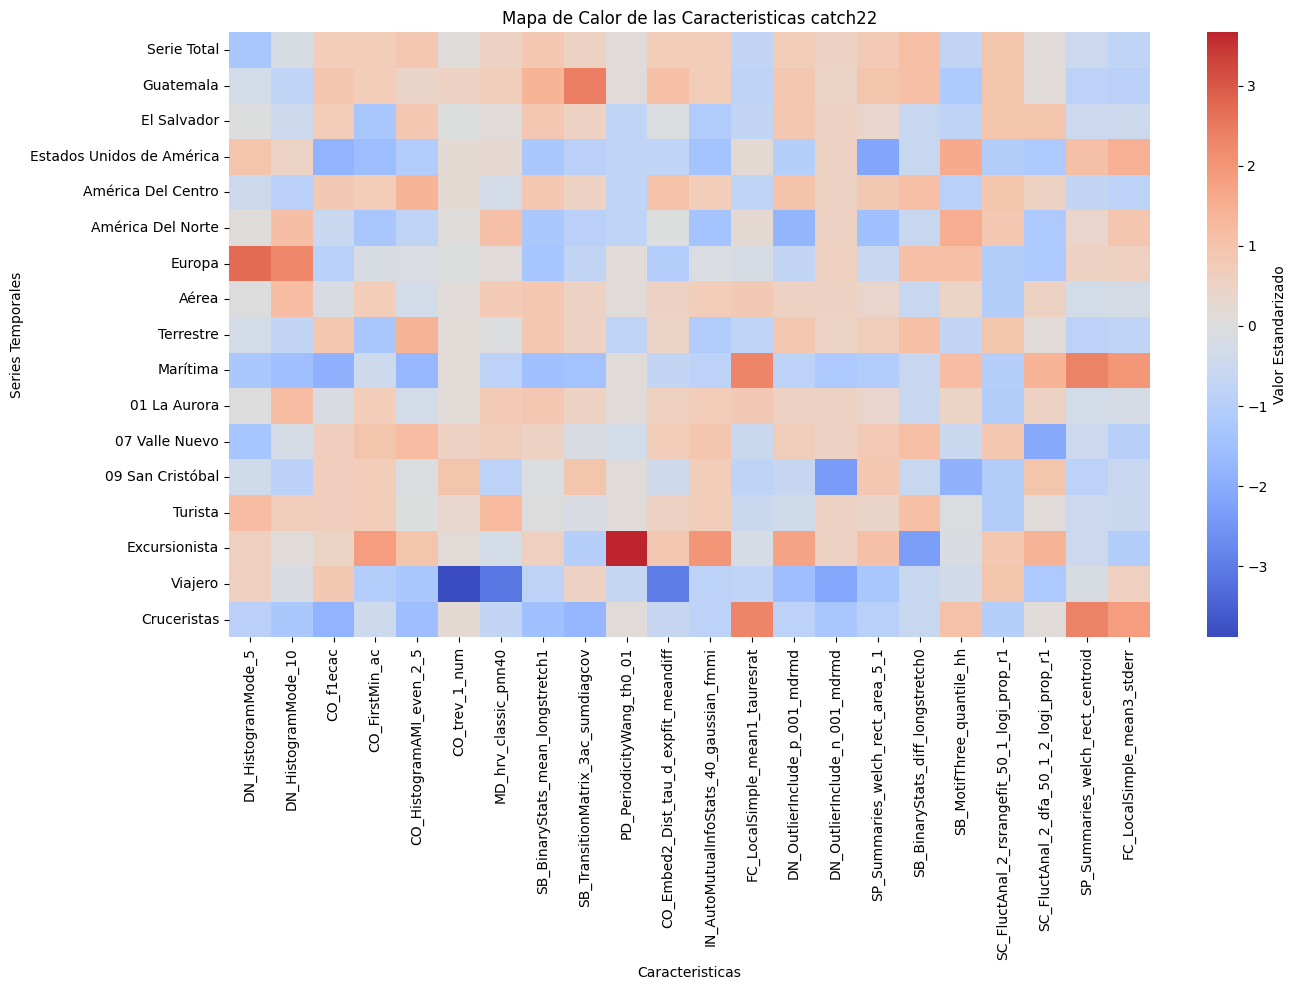

In [ ]:
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_caracteristicas_std, cmap='coolwarm', center=0, cbar_kws={'label': 'Valor Estandarizado'}, yticklabels=True)
plt.title('Mapa de Calor de las Caracteristicas catch22')
plt.xlabel('Caracteristicas')
plt.ylabel('Series Temporales')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El mapa de calor de las caracteristicas estandarizadas revela como se distribuyen las magnitudes de cada metrica de catch22 a traves de las distintas series temporales. Se identifica que un amplio sector de las series comparte una coloracion neutra o muy similar en la mayor parte de las caracteristicas, lo que apunta a un comportamiento uniforme generalizado. No obstante, se aprecia que un subconjunto reducido de series presenta bandas de colores muy intensos, lo que sugiere que estas manifiestan valores extremos en metricas especificas que las distinguen del resto de los datos.

### 2.5.4. Matriz de Correlaciones entre Características

La matriz de correlaciones cuantifica la dependencia lineal cruzada entre las veintidos caracteristicas de catch22 extraidas del conjunto de datos. Representar esta matriz mediante un mapa de calor facilita la identificacion de variables redundantes o metricas que capturan propiedades inversamente proporcionales del comportamiento temporal.

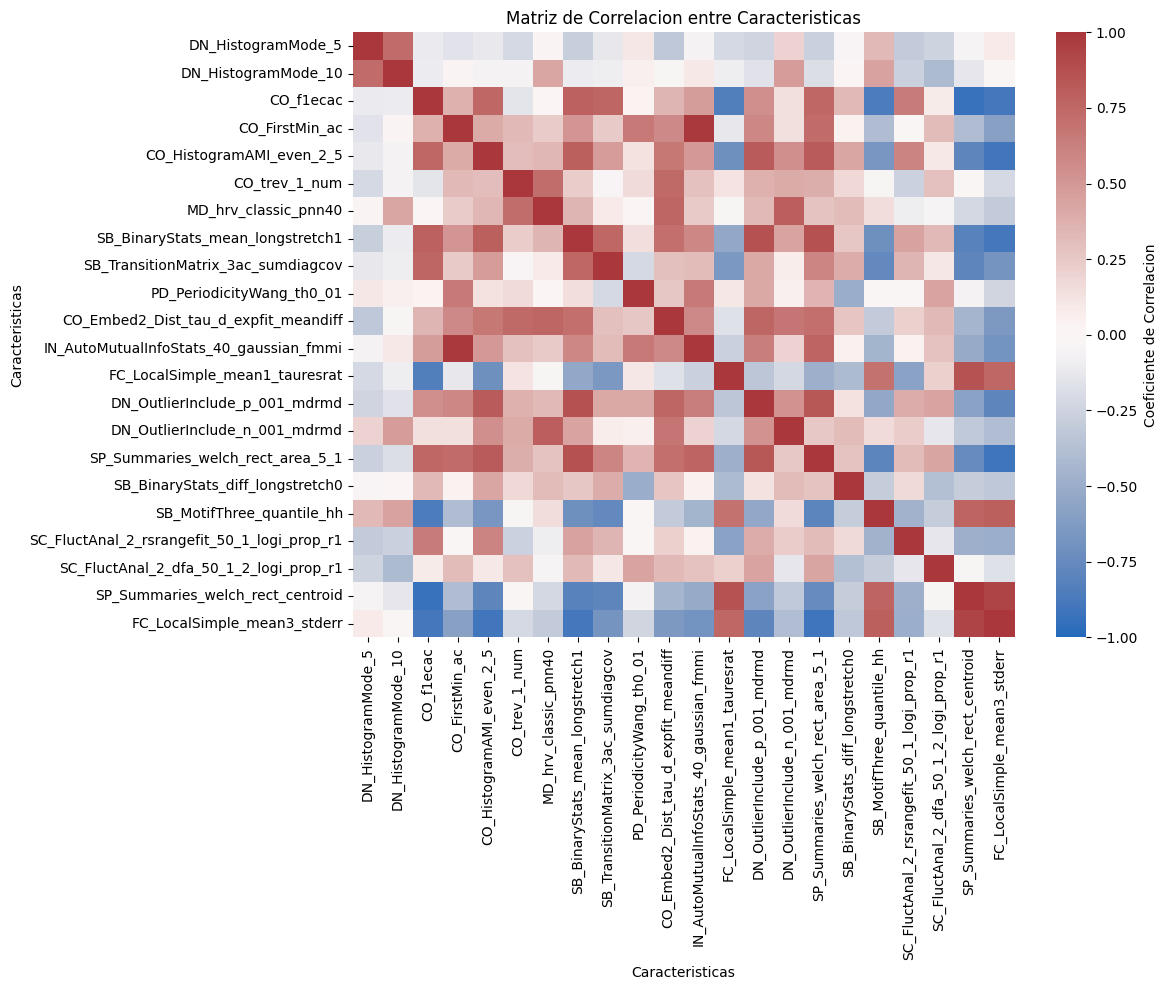

In [ ]:
matriz_correlacion = matriz_caracteristicas_std.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, cmap='vlag', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Coeficiente de Correlacion'})
plt.title('Matriz de Correlacion entre Caracteristicas')
plt.xlabel('Caracteristicas')
plt.ylabel('Caracteristicas')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La matriz de correlacion entre las caracteristicas de catch22 muestra el grado de asociacion lineal existente entre los diferentes atributos extraidos. Se observa la presencia de bloques con tonos calidos que indican fuertes correlaciones positivas entre ciertos grupos de variables, lo que sugiere que varias metricas podrian estar capturando propiedades similares de las series temporales. Asimismo, pueden identificarse zonas con colores frios intensos que reflejan relaciones inversamente proporcionales, evidenciando que el conjunto de variables abarca comportamientos contrastantes.

### 2.5.5. Mapa de Distancias entre Series

El calculo de la matriz de distancias euclidianas mide la separacion espacial absoluta entre cada par de series temporales basandose en sus caracteristicas multivariadas. Visualizar esta metrica en un mapa de calor cruzado permite evaluar de manera directa que series individuales son mas semejantes o diferentes entre si en su estructura estadistica.

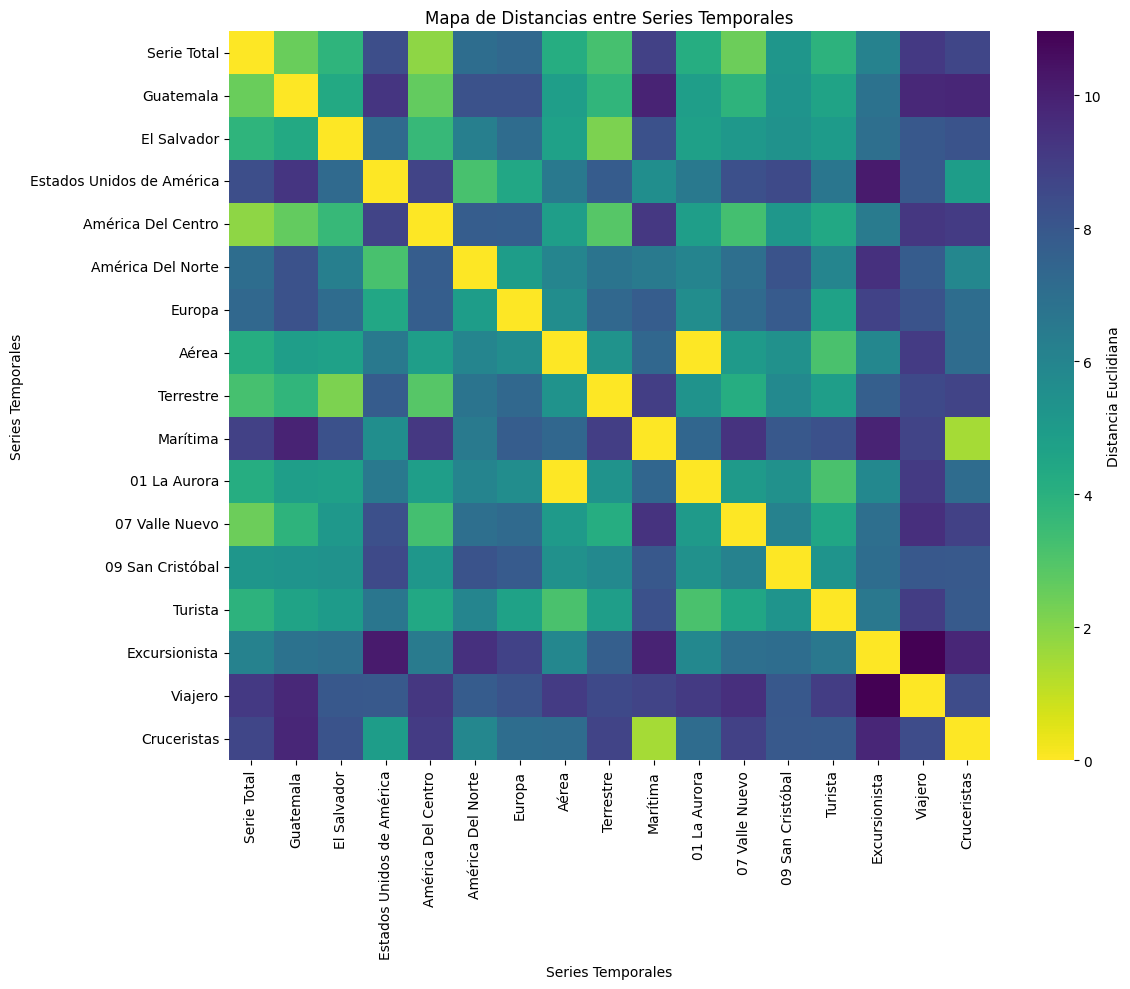

In [ ]:
from scipy.spatial.distance import pdist, squareform

# Calculo de distancia euclidiana entre vectores estandarizados
distancias_array = pdist(matriz_caracteristicas_std, metric='euclidean')
matriz_distancias = squareform(distancias_array)

df_distancias = pd.DataFrame(
    matriz_distancias,
    index=matriz_caracteristicas_std.index,
    columns=matriz_caracteristicas_std.index
)

plt.figure(figsize=(12, 10))
sns.heatmap(df_distancias, cmap='viridis_r', cbar_kws={'label': 'Distancia Euclidiana'})
plt.title('Mapa de Distancias entre Series Temporales')
plt.xlabel('Series Temporales')
plt.ylabel('Series Temporales')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

El mapa de distancias euclidianas expone la separacion absoluta entre cada par de series temporales evaluadas dentro del espacio de caracteristicas. La predominancia de tonos oscuros en gran parte de la matriz sugiere que la mayoria de las series guardan una distancia muy corta entre si, conformando un nucleo de datos bastante afin. Sin embargo, se aprecia que un grupo reducido de series especificas genera franjas de colores claros al ser comparadas transversalmente, lo que indica una mayor disimilitud y corrobora que se alejan del patron que caracteriza a la mayor parte de la base.

# 2.7 Series presentan comportamientos más similares

Las series con comportamientos similares son:
1. Aérea y 01 la aurora, con una distancia euclidiana igual a cero en el mapa de distancias y coinciden en el plano PCA.
2. Maritimas y cruceristas, cuentan con una distancia reducida en la matriz de distancia y se agrupan en grupo 2 de k-means
3. Serie total, Guatemala,América del centro y 07 Valle Nuevo, con distancia euclidiana reducida, y se agrupan en el grupo 1.

Nótese que tanto la matriz de distancias y el PCA y k-means muestran cualitativamente que la trayectoria de sus características de catch22 es casi identica.

# 2.8 Características importantes de catch22 para diferenciar las series

Basándonos en el mapa de calor de características y la matriz de correlación, las características determinantes serian:

1. Periocidad (PD_PeriodicityWang_th0_01): Hay variabilidad extrema tomando valores positivos muy altos en Excursionista.
2. Propiedades temporales no lineales: Muestra valores en estremo negativos en la serie viajero, siendo esto atípico.
3. SP_Summaries_welch_rect_area_5_1 y FC_LocalSimple_mean3_stderr muestran una correlación directa en la matriz de correlación, además de ser distintivos para el bloque Marítima y Cruceristas.

#2.9 Los grupos naturales en la serie
1. Grupo 0  (Estados Unidos de América, América Del Norte, Europa): Muestran distancias relativamente largas respecto al tránsito y comparten patrones demográficos.
2. Grupo 1 (Serie Total, El Salvador,	Guatemala, América Del Centro, Aérea, terrestre, 01 La Aurora, 10	07 Valle Nuevo, 11	09 San Cristóbal, 12	Excursionista, 13	Turista) Con distancias euclidianas bajas entre si, al estar dominados por frontera terreste regional.
3. Grupo 2(Marítima, 15	Cruceristas): Con distancia euclidana casi nula, entre ellas, pero altas comparado a las vías terrestes.
4. Grupo 3 (16	Viajero	3): Mustran gran distancia euclidiana con casi todas las series.

Estos grupos son identificados de forma óptima por el coefuciente de Silhouette(k=4)

#2.10 Series en una misma categoría

Hay tendencia a agruparse por categoría, donde se nota la lógica operativa y geográfica. La vía de ingreso hay una gran coincidencia entre vía aerea y la 01 La Aurora, mientras que la marítima con Cruceristas. Entre paises y regiones como Guatemala y El Salvador y la región América del Centro estan en el mismo cluster. Turista y Excursionista mantienen el mismo flujo ya sea terreste o aéreo, mientras que Viajero presenta una distancia eucludiana maxima a comparativa con las demás.